# Evaluate — DDPG A1 & A2, TD3 A1 & A2 on Juan's 4 days

Loads the four CURRENT best policies (`policies/*_best.pt`, trained in the tuned
stability-safe gain box `GAIN_LOW=[-30,-4.0,-0.4]`) and evaluates them on the four
newest Juan days: metrics table (MAE / RMSE / peak overshoot / undershoot) vs the
expert PI, one tracking chart per day (all four policies + expert), and the applied
flow. Charts are saved under `charts/evaluate/`. Evaluation only — no training.


In [1]:
# ── Setup: shared library (../main_script) + this folder's config ────────────
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch
sys.path.insert(0, os.getcwd())                                            # for: import config
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), os.pardir)))  # reach ../main_script
from main_script import *
import config as cfg
from config import *
configure(cfg)

# ══ ONE SWITCH: which generation to evaluate ══════════════════════════════════
# False -> TUNED policies (policies/*_best.pt, wide stability-safe box)
# True  -> OLD-window policies (policies/old_box/*_best_oldbox.pt, narrow box)
# The gain box, policy paths, chart filenames and CSV all flip TOGETHER, so the
# two generations can never be mixed or overwrite each other's outputs.
USE_OLD_BOX = False

if USE_OLD_BOX:
    GEN = 'old-window'; SUFFIX = '_oldbox'
    cfg.GAIN_LOW  = np.array([-6.0, -0.100, -0.60], dtype=np.float32)
    POLICIES = {
        'DDPG-A1': os.path.join('old_box', 'ddpg_online_ac_approach1_best_oldbox.pt'),
        'DDPG-A2': os.path.join('old_box', 'ddpg_online_ac_approach2_best_oldbox.pt'),
        'TD3-A1':  os.path.join('old_box', 'td3_online_ac_approach1_best_oldbox.pt'),
        'TD3-A2':  os.path.join('old_box', 'td3_online_ac_approach2_best_oldbox.pt'),
    }
else:
    GEN = 'tuned'; SUFFIX = ''
    cfg.GAIN_LOW  = np.array([-30.0, -4.0, -0.40], dtype=np.float32)
    POLICIES = {
        'DDPG-A1': 'ddpg_online_ac_approach1_best.pt',
        'DDPG-A2': 'ddpg_online_ac_approach2_best.pt',
        'TD3-A1':  'td3_online_ac_approach1_best.pt',
        'TD3-A2':  'td3_online_ac_approach2_best.pt',
    }
cfg.GAIN_HIGH = np.array([-0.05, -0.0001, 0.10], dtype=np.float32)

COLORS = {'DDPG-A1': '#d62728', 'DDPG-A2': '#ff7f0e', 'TD3-A1': '#1f77b4', 'TD3-A2': '#9467bd'}
actors = {tag: load_actor_raw(os.path.join(SAVE_DIR, f)) for tag, f in POLICIES.items()}

EV_DIR = os.path.join(CHART_DIR, 'evaluate'); os.makedirs(EV_DIR, exist_ok=True)

def undershoot_metric(T, tref):
    """Worst dip below T_ref AFTER the first crossing (startup climb excluded)."""
    above = np.nonzero(T >= tref)[0]
    return float(np.max(tref - T[above[0]:])) if len(above) else float(np.max(tref - T))

print(f"[{GEN}] loaded {len(actors)} policies | decode box LOW={list(cfg.GAIN_LOW)} HIGH={list(cfg.GAIN_HIGH)}")


[load] raw actor from ddpg_online_ac_approach1_best.pt
[load] raw actor from ddpg_online_ac_approach2_best.pt
[load] raw actor from td3_online_ac_approach1_best.pt
[load] raw actor from td3_online_ac_approach2_best.pt
[tuned] loaded 4 policies | decode box LOW=[np.float32(-30.0), np.float32(-4.0), np.float32(-0.4)] HIGH=[np.float32(-0.05), np.float32(-1e-04), np.float32(0.1)]


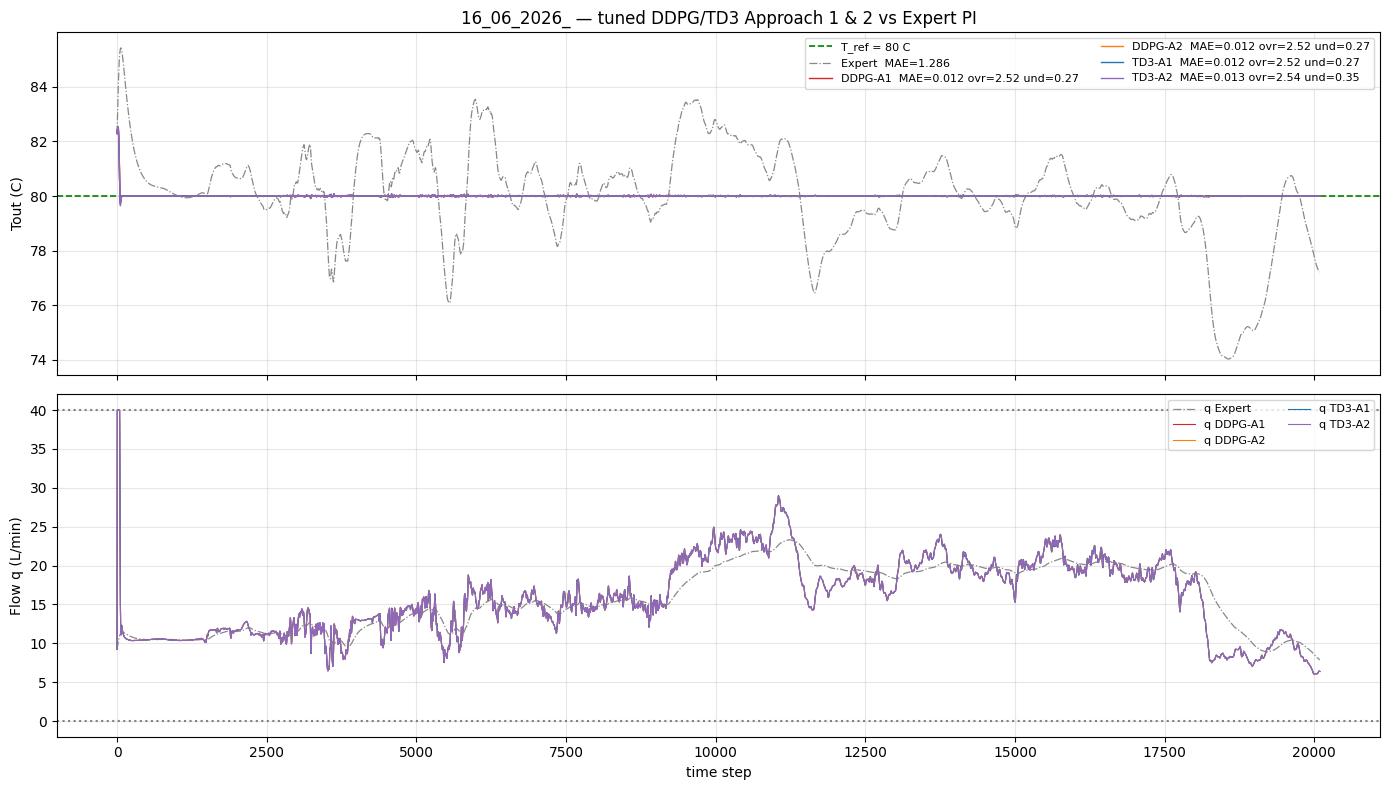

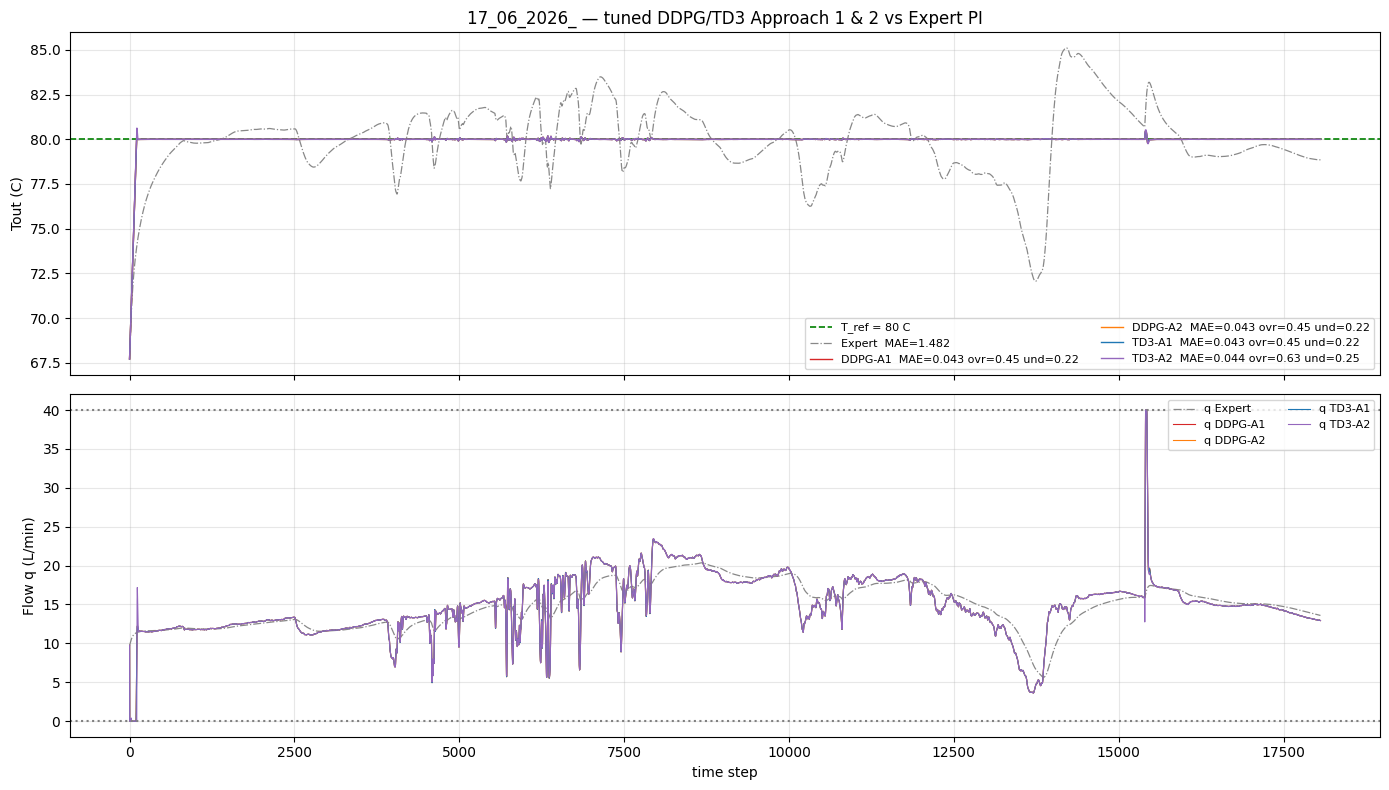

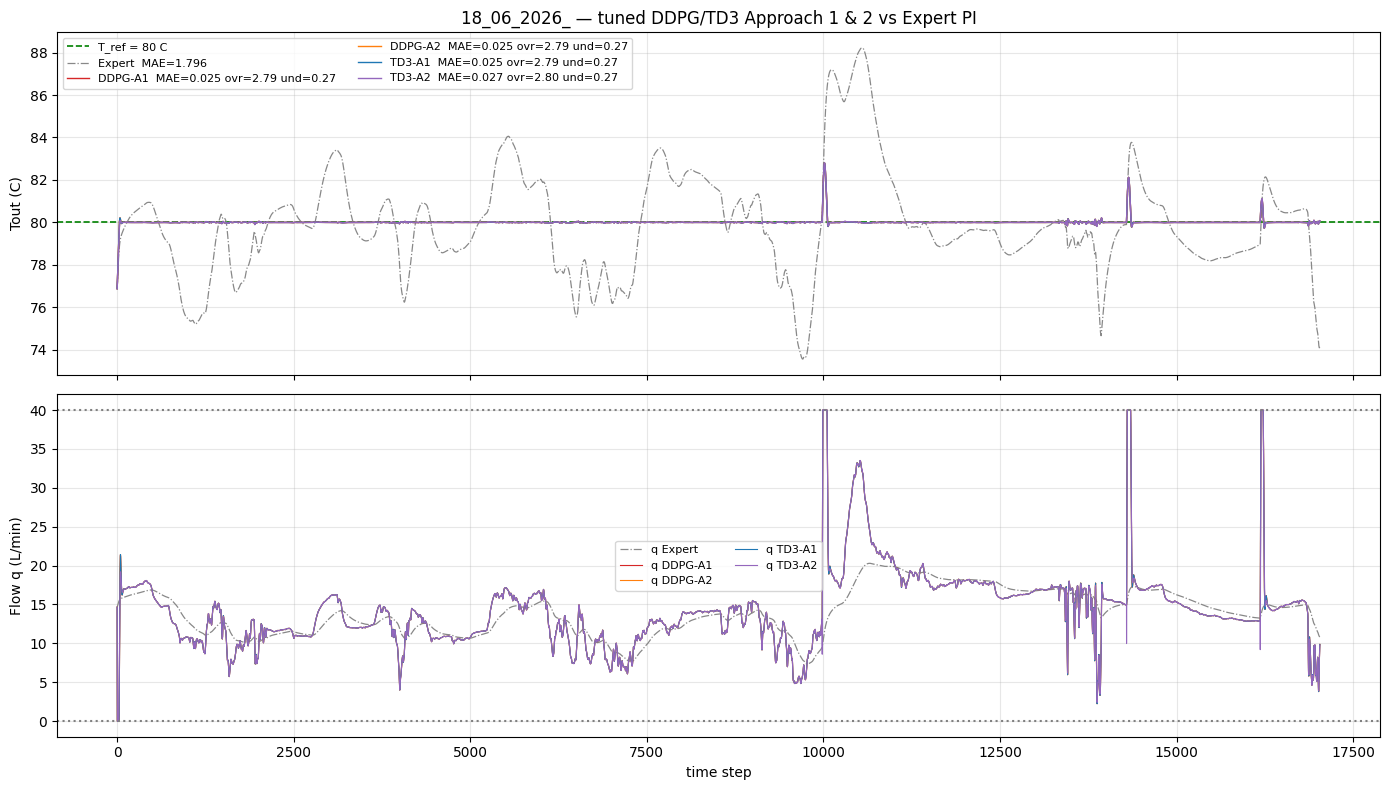

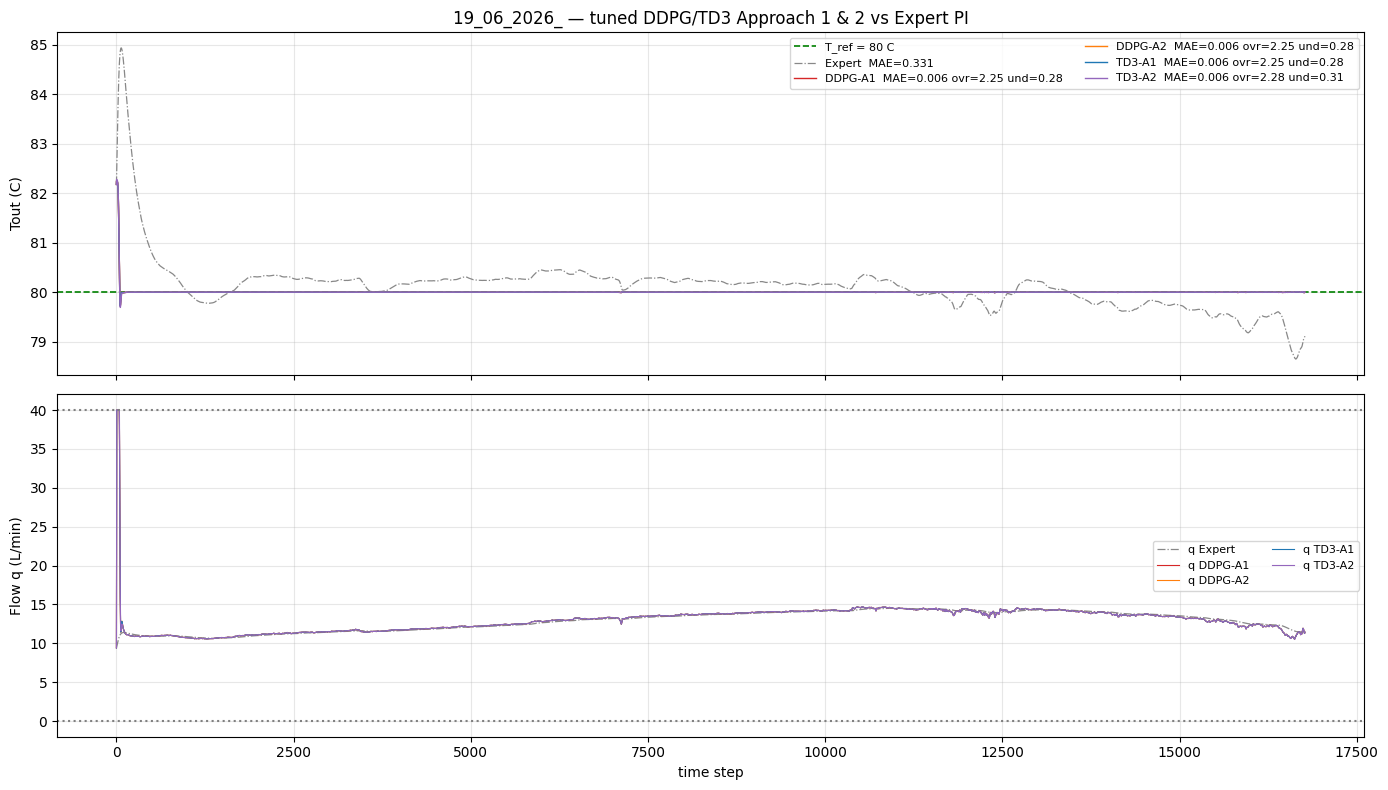

Per-day metrics:


,day,policy,MAE,RMSE,ovr,und
0,16_06_2026_,Expert,1.286,1.806,5.425,5.972
1,16_06_2026_,DDPG-A1,0.012,0.102,2.519,0.265
2,16_06_2026_,DDPG-A2,0.012,0.102,2.519,0.266
3,16_06_2026_,TD3-A1,0.012,0.102,2.519,0.266
4,16_06_2026_,TD3-A2,0.013,0.103,2.542,0.354
5,17_06_2026_,Expert,1.482,2.079,5.117,7.945
6,17_06_2026_,DDPG-A1,0.043,0.546,0.453,0.219
7,17_06_2026_,DDPG-A2,0.043,0.546,0.452,0.219
8,17_06_2026_,TD3-A1,0.043,0.546,0.452,0.219
9,17_06_2026_,TD3-A2,0.044,0.547,0.626,0.245


Summary [tuned] over the 4 Juan days (mean MAE/RMSE; worst-day ovr/und):


,MAE,RMSE,ovr_worst,und_worst
policy,,,,
Expert,1.224,1.731,8.219,7.945
DDPG-A1,0.022,0.232,2.794,0.278
DDPG-A2,0.022,0.232,2.794,0.278
TD3-A1,0.022,0.232,2.794,0.278
TD3-A2,0.022,0.233,2.802,0.354


In [2]:
# ── STATE vs time: metrics table + one chart per day (Tout + applied flow) ───
days = [load_dataset(f) for f in JUAN_FILES]

rows = []
for d in days:
    tr = dataset_tref(d['name'])
    Te, Qe = rollout_expert(d)
    m, rm = mae_rmse(Te, tr)
    rows.append(dict(day=d['name'][:11], policy='Expert', MAE=m, RMSE=rm,
                     ovr=peak_overshoot(Te, tr), und=undershoot_metric(Te, tr)))
    Ts = {}; Qs = {}
    for tag, actor in actors.items():
        T, Q, G = rollout_full(actor, d); Ts[tag] = T; Qs[tag] = Q
        m, rm = mae_rmse(T, tr)
        rows.append(dict(day=d['name'][:11], policy=tag, MAE=m, RMSE=rm,
                         ovr=peak_overshoot(T, tr), und=undershoot_metric(T, tr)))

    # chart: Tout (top, all policies + expert) and applied flow q (bottom)
    t = np.arange(len(Te))
    fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ax[0].axhline(tr, ls='--', c='green', lw=1.2, label=f'T_ref = {tr:.0f} C')
    ax[0].plot(t, Te, c='#888888', ls='-.', lw=0.9, label=f'Expert  MAE={rows[-5]["MAE"]:.3f}')
    for tag in POLICIES:
        mt = [r for r in rows if r['day'] == d['name'][:11] and r['policy'] == tag][0]
        ax[0].plot(np.arange(len(Ts[tag])), Ts[tag], c=COLORS[tag], lw=1.0,
                   label=f"{tag}  MAE={mt['MAE']:.3f} ovr={mt['ovr']:.2f} und={mt['und']:.2f}")
    ax[0].set_ylabel('Tout (C)'); ax[0].grid(alpha=.3); ax[0].legend(fontsize=8, ncol=2)
    ax[0].set_title(f"{d['name'][:11]} — {GEN} DDPG/TD3 Approach 1 & 2 vs Expert PI")
    ax[1].plot(t, Qe, c='#888888', ls='-.', lw=0.9, label='q Expert')
    for tag in POLICIES:
        ax[1].plot(np.arange(len(Qs[tag])), Qs[tag], c=COLORS[tag], lw=0.8, label=f'q {tag}')
    ax[1].axhline(Q_MIN, color='gray', ls=':'); ax[1].axhline(Q_MAX, color='gray', ls=':')
    ax[1].set_ylabel('Flow q (L/min)'); ax[1].set_xlabel('time step'); ax[1].grid(alpha=.3)
    ax[1].legend(fontsize=8, ncol=2)
    fig.tight_layout()
    fig.savefig(os.path.join(EV_DIR, f"evaluate_day_{d['name'][:11]}{SUFFIX}.png"),
                dpi=140, bbox_inches='tight')
    plt.show(); plt.close(fig)

df = pd.DataFrame(rows)
print('Per-day metrics:')
display(df.round(3))
summ = df.groupby('policy').agg(MAE=('MAE', 'mean'), RMSE=('RMSE', 'mean'),
                                ovr_worst=('ovr', 'max'), und_worst=('und', 'max'))
summ = summ.loc[['Expert', 'DDPG-A1', 'DDPG-A2', 'TD3-A1', 'TD3-A2']]
print(f'Summary [{GEN}] over the 4 Juan days (mean MAE/RMSE; worst-day ovr/und):')
display(summ.round(3))
df.to_csv(os.path.join(EV_DIR, f'evaluate_juan_days{SUFFIX}.csv'), index=False)


In [ ]:
# ── ACTION vs time (with Expert PI): one chart per day (Kp, Ki, Kw + flow q) ──
# Same style as the state chart above: all four policies + the expert reference.
# The gains are the actor's ACTIONS decoded through the active gain box.
EXP_G = {'Kp': KP_EXPERT, 'Ki': KI_EXPERT, 'Kw': KI_EXPERT / KP_EXPERT}
ACT_ROWS = [('Kp', 'Kp  [-]'), ('Ki', 'Ki  [-]'), ('Kw', 'Kw (anti-windup)  [-]'),
            ('q',  'flow q  [L/min]')]

ACT_G = {}; ACT_Q = {}          # cached rollouts, reused by the RL-only cell below
for d in days:
    tr = dataset_tref(d['name'])
    Te, Qe = rollout_expert(d)
    Gs = {}; Qs = {}
    for tag, actor in actors.items():
        T, Q, G = rollout_full(actor, d)
        Gs[tag] = G; Qs[tag] = Q
    ACT_G[d['name']] = Gs; ACT_Q[d['name']] = Qs

    fig, ax = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    for r, (key, ylab) in enumerate(ACT_ROWS):
        if key == 'q':
            t = np.arange(len(Qe))
            ax[r].plot(t, Qe, c='#888888', ls='-.', lw=0.9, label='Expert PI')
            for tag in POLICIES:
                ax[r].plot(np.arange(len(Qs[tag])), Qs[tag], c=COLORS[tag], lw=0.8, label=tag)
            ax[r].axhline(Q_MIN, color='gray', ls=':'); ax[r].axhline(Q_MAX, color='gray', ls=':')
            ax[r].set_xlabel('time step')
        else:
            gi = {'Kp': 0, 'Ki': 1, 'Kw': 2}[key]
            ax[r].axhline(EXP_G[key], ls='-.', c='#888888', lw=0.9,
                          label=f'Expert ({EXP_G[key]:.4f})')
            for tag in POLICIES:
                ax[r].plot(np.arange(len(Gs[tag])), Gs[tag][:, gi], c=COLORS[tag], lw=0.8, label=tag)
        ax[r].set_ylabel(ylab); ax[r].grid(alpha=.3)
        if r == 0:
            ax[r].legend(fontsize=8, ncol=3)
            ax[r].set_title(f"{d['name'][:11]} — {GEN} policies: actions applied at each time step")
    fig.tight_layout()
    fig.savefig(os.path.join(EV_DIR, f"evaluate_actions_day_{d['name'][:11]}{SUFFIX}.png"),
                dpi=140, bbox_inches='tight')
    plt.show(); plt.close(fig)


In [ ]:
# ── ACTION vs time (RL policies ONLY, no Expert PI) ──────────────────────────
# The expert's constant gains (Kp=-0.5, Ki=-0.0017) are on a far smaller scale
# than the RL gains, so this version omits them to keep the RL actions readable.
# Reuses the rollouts cached by the cell above; saves to *_rlonly_* filenames so
# the original charts (with the expert reference) are never overwritten.
for d in days:
    Gs = ACT_G[d['name']]; Qs = ACT_Q[d['name']]
    fig, ax = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    for r, (key, ylab) in enumerate(ACT_ROWS):
        if key == 'q':
            for tag in POLICIES:
                ax[r].plot(np.arange(len(Qs[tag])), Qs[tag], c=COLORS[tag], lw=0.8, label=tag)
            ax[r].axhline(Q_MIN, color='gray', ls=':'); ax[r].axhline(Q_MAX, color='gray', ls=':')
            ax[r].set_xlabel('time step')
        else:
            gi = {'Kp': 0, 'Ki': 1, 'Kw': 2}[key]
            for tag in POLICIES:
                ax[r].plot(np.arange(len(Gs[tag])), Gs[tag][:, gi], c=COLORS[tag], lw=0.8, label=tag)
        ax[r].set_ylabel(ylab); ax[r].grid(alpha=.3)
        if r == 0:
            ax[r].legend(fontsize=8, ncol=4)
            ax[r].set_title(f"{d['name'][:11]} — {GEN} policies: actions applied at each time step "
                            f"(RL only)")
    fig.tight_layout()
    fig.savefig(os.path.join(EV_DIR, f"evaluate_actions_rlonly_day_{d['name'][:11]}{SUFFIX}.png"),
                dpi=140, bbox_inches='tight')
    plt.show(); plt.close(fig)
